In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv("ad_spend.csv")
df.head()

,Ad Spend ($),Season,Revenue ($)
0,463,Monsoon,440
1,158,Winter,297
2,328,Monsoon,214
3,322,Monsoon,48
4,726,Winter,1048


In [2]:
df.shape

(200, 3)

In [5]:
g =df.groupby("Season")[["Ad Spend ($)", "Revenue ($)"]].mean()
g

,Ad Spend ($),Revenue ($)
Season,,
Monsoon,517.643836,423.150685
Summer,573.836066,689.360656
Winter,552.560606,826.530303


Text(0.5, 1.0, 'Average Ad Spend and Revenue by Season')

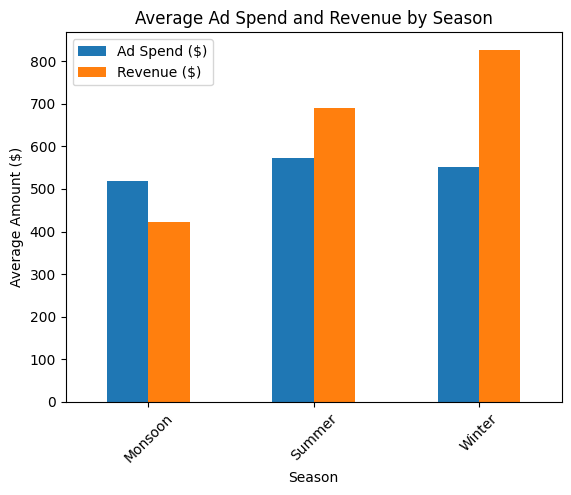

In [8]:
ax =g.plot(kind="bar")
ax.set_xlabel("Season")
ax.set_ylabel("Average Amount ($)")
ax.set_title("Average Ad Spend and Revenue by Season")
plt.xticks(rotation=45)
plt.title("Average Ad Spend and Revenue by Season")

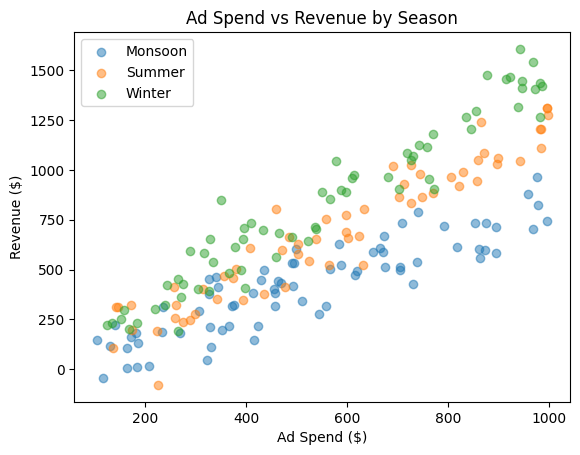

In [9]:
for season, subdf in df.groupby("Season"):
    plt.scatter(subdf["Ad Spend ($)"], subdf["Revenue ($)"], label=season, alpha=0.5)
plt.xlabel("Ad Spend ($)")
plt.ylabel("Revenue ($)")
plt.title("Ad Spend vs Revenue by Season")
plt.legend()
plt.show()

In [10]:
df_encoded = pd.get_dummies(df, columns=["Season"], drop_first=True)
df_encoded.head()

,Ad Spend ($),Revenue ($),Season_Summer,Season_Winter
0,463,440,False,False
1,158,297,False,True
2,328,214,False,False
3,322,48,False,False
4,726,1048,False,True


In [11]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop("Revenue ($)", axis=1)
y = df_encoded["Revenue ($)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Train linear Regression model


In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8753247249087288

### Train Decision Tree Regressor

In [15]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7861611880674995

### Train GDM

In [24]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=42, n_estimators=50, learning_rate=0.1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.871387927825966

In [18]:
y_pred = model.predict(X_test)
df_eval = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df_eval.head()

,Actual,Predicted
95,903,954.462814
15,1047,871.587571
30,1026,871.950129
158,1203,1289.316134
128,558,667.819039


In [19]:
df_eval["Diff %"] = abs((df_eval["Predicted"] - df_eval["Actual"])*100 / df_eval["Actual"])
df_eval

,Actual,Predicted,Diff %
95,903,954.462814,5.699093
15,1047,871.587571,16.753814
30,1026,871.950129,15.014607
158,1203,1289.316134,7.175074
128,558,667.819039,19.680831
115,354,473.819227,33.847239
69,1446,1460.144733,0.978197
170,108,273.567756,153.303478
174,375,278.453168,25.745822
45,522,543.837190,4.183370


In [20]:
df_eval["Diff %"] = (df_eval["Predicted"] - df_eval["Actual"]) / df_eval["Actual"] * 100
df_eval.head()

,Actual,Predicted,Diff %
95,903,954.462814,5.699093
15,1047,871.587571,-16.753814
30,1026,871.950129,-15.014607
158,1203,1289.316134,7.175074
128,558,667.819039,19.680831
